In [13]:
import random
import math
import numpy as np
from deap import base
from deap import creator
from deap import tools
from deap import algorithms
import matplotlib.pyplot as plt

Text(0.5, 0, 'f(x, y)')

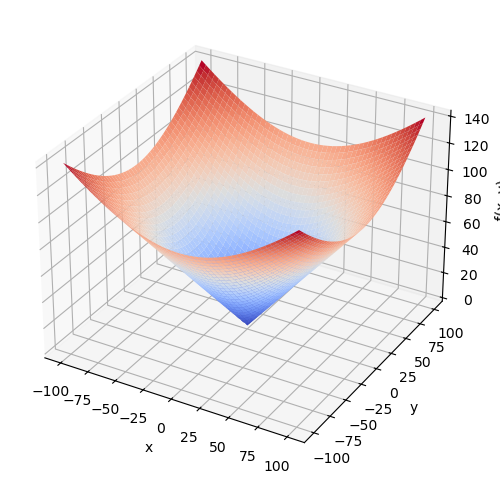

In [15]:
from matplotlib import cm

def funcion_prueba(x):
    res = np.sqrt(x[0]**2 + x[1]**2)
    return res

x = np.linspace(-100, 100, 1000)
y = np.linspace(-100, 100, 1000)

x_ax, y_ax = np.meshgrid(x, y)
vals = np.c_ [x_ax.ravel(), y_ax.ravel()]
fx = np.reshape([funcion_prueba(val) for val in vals], (1000, 1000))

figure3d = plt.figure(figsize=(8, 6))
ax = figure3d.add_subplot(111, projection='3d')

ax.plot_surface(x_ax, y_ax, fx, cmap=cm.coolwarm)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('f(x, y)')

3. Definición del problema
- Tipo de problema de optimización: maximización
- Tipo de objeto: Lista
- Toolbox:
    - Función para crear individuo
    - Función para crear la población

4. Creación del problema <br>
Se utiliza el método create() de la clase creator, para crear la clase llamada FitnessMax,
subclase de la clase base base.Fitness, agregando el atributo weights.


In [2]:
creator.create("FitnessMax", base.Fitness, weights=(1.0,))

5. Creación del individuo<br>
El método créate() se utiliza para definir la clase que encapsula al individuo:


In [3]:
creator.create("Individual", list, fitness=creator.FitnessMax)

6. Crear individuos aleatorios y población inicial

In [4]:
toolbox = base.Toolbox()

In [5]:
# Generación de genes
toolbox.register("attr_uniform", random.uniform, -100, 100)

In [7]:
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_uniform, 2)

In [22]:
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

7. Función objetivo.

In [9]:
def funcion_objetivo(x):
    for i in range(len(x)):
        if x[i] > 100 or x[i] < -100:
            return -1,
    res = math.sqrt(x[0]**2 + x[1]**2)
    return res,

Aplicación del fitness

In [10]:
toolbox.register("evaluate", funcion_objetivo)

Operadores genéticos

In [11]:
toolbox.register("mate", tools.cxOnePoint)
toolbox.register("mutate", tools.mutGaussian, mu=0, sigma=5, indpb=0.1)
toolbox.register("select", tools.selTournament, tournsize=3)

10. Configuración del algoritmo genético

gen	nevals	avg    	std   	min    	max    
0  	10    	81.3622	28.287	31.2954	116.497
1  	2     	108.322	14.1648	71.337 	126.071
2  	7     	116.868	9.20852	98.8946	136.779
3  	4     	121.084	8.49836	112.226	136.779
4  	7     	125.454	8.40708	116.497	136.779
5  	4     	135.519	3.19937	126.071	136.779
6  	5     	136.779	0      	136.779	136.779
7  	5     	136.779	0      	136.779	136.779
8  	10    	136.779	0      	136.779	136.779
9  	4     	136.358	1.26178	132.573	136.779
10 	6     	136.779	0      	136.779	136.779
11 	6     	136.779	0      	136.779	136.779
12 	7     	136.779	0      	136.779	136.779
13 	7     	136.779	0      	136.779	136.779
14 	8     	122.639	41.2271	-1     	136.779
15 	6     	136.779	0      	136.779	136.779
16 	5     	136.779	0      	136.779	136.779
17 	6     	136.779	0      	136.779	136.779
18 	6     	136.779	0      	136.779	136.779
19 	6     	136.452	0.980645	133.51 	136.779
20 	4     	136.779	0       	136.779	136.779
Mejor fitness: 136.77889635502862
Mejor individuo: [-9

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


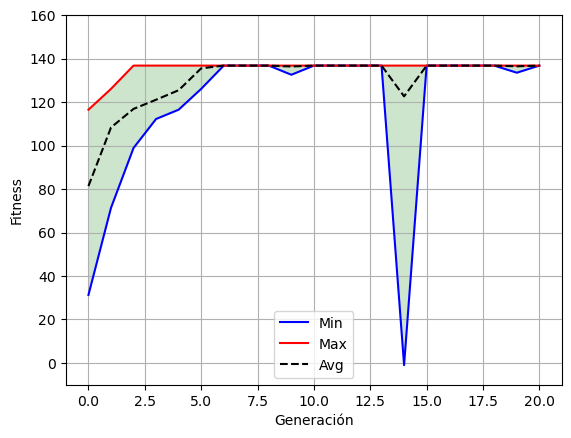

In [ ]:
def main():
    random.seed(42)
    CXPB, MUTPB, NGEN = 0.5, 0.2, 20
    pop = toolbox.population(n=10)
    hof = tools.HallOfFame(1)
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("avg", np.mean)
    stats.register("std", np.std)
    stats.register("min", np.min)
    stats.register("max", np.max)
    logbook = tools.Logbook()
    pop, logbook = algorithms.eaSimple(pop, toolbox, cxpb=CXPB, mutpb=MUTPB, ngen=NGEN, stats=stats, halloffame=hof, verbose=True)
    return hof, logbook

if __name__ == "__main__":
    best, log = main()
    print(f"Mejor fitness: {best[0].fitness.values[0]}")
    print(f"Mejor individuo: {best[0]}")
    plot_evolucion(log)

11. Convergencia del algoritmo<br>
La función plot_evolucion() se debe ejecutar una vez termine el algoritmo genético

In [17]:
def plot_evolucion(log):
    gen = np.array(log.select("gen"))
    fit_mins = np.array(log.select("min"), dtype=float)
    fit_maxs = np.array(log.select("max"), dtype=float)
    fit_ave = np.array(log.select("avg"), dtype=float)
    
    fig, ax1 = plt.subplots()
    ax1.plot(gen, fit_mins, "b")
    ax1.plot(gen, fit_maxs, "r")
    ax1.plot(gen, fit_ave, "--k")
    where_mask = fit_maxs >= fit_mins
    ax1.fill_between(gen, fit_mins, fit_maxs, where=where_mask, facecolor="g", alpha=0.2)
    ax1.set_xlabel("Generación")
    ax1.set_ylabel("Fitness")
    ax1.set_ylim([-10, 160])
    ax1.legend(["Min", "Max", "Avg"], loc="lower center")
    plt.grid(True)
    plt.savefig("Convergencia.eps", dpi=300)

### **14. Implementar el algoritmo para una población de 30 y 50 individuos, con 20 generaciones, Hacer una tabla comparativa de los resultados obtenidos y las gráficas de convergencia.**

In [23]:
def ejecutar_experimento(tam_poblacion):
    random.seed(42)
    np.random.seed(42)
    
    CXPB, MUTPB, NGEN = 0.5, 0.2, 20
    pop = toolbox.population(n=tam_poblacion)
    hof = tools.HallOfFame(1)
    
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("avg", np.mean)
    stats.register("std", np.std)
    stats.register("min", np.min)
    stats.register("max", np.max)
    
    pop, logbook = algorithms.eaSimple(pop, toolbox, cxpb=CXPB, mutpb=MUTPB, ngen=NGEN, stats=stats, halloffame=hof, verbose=True)
    
    return {
        "poblacion": tam_poblacion,
        "mejor_fitness": hof[0].fitness.values[0],
        "mejor_individuo": hof[0],
        "fitness_promedio_final": logbook.select("avg")[-1],
        "fitness_min_final": logbook.select("min")[-1],
        "fitness_max_final": logbook.select("max")[-1],
        "logbook": logbook
    }

In [30]:
%%capture
resultado_30 = ejecutar_experimento(30)
resultado_50 = ejecutar_experimento(50)

In [34]:
import pandas as pd

tabla_comparativa = pd.DataFrame([
    {
        "Población": resultado_30["poblacion"],
        "Mejor fitness": resultado_30["mejor_fitness"],
        "Fitness promedio final": resultado_30["fitness_promedio_final"],
        "Fitness mínimo final": resultado_30["fitness_min_final"],
        "Fitness máximo final": resultado_30["fitness_max_final"],
        "Mejor individuo": resultado_30["mejor_individuo"]
    },
    {
        "Población": resultado_50["poblacion"],
        "Mejor fitness": resultado_50["mejor_fitness"],
        "Fitness promedio final": resultado_50["fitness_promedio_final"],
        "Fitness mínimo final": resultado_50["fitness_min_final"],
        "Fitness máximo final": resultado_50["fitness_max_final"],
        "Mejor individuo": resultado_50["mejor_individuo"]
    }
])

tabla_comparativa

,Población,Mejor fitness,Fitness promedio final,Fitness mínimo final,Fitness máximo final,Mejor individuo
0,30,140.100794,140.066634,139.075983,140.100794,"[-99.34638537370458, -98.78526358100852]"
1,50,140.676643,137.843110,-1.000000,140.676643,"[99.47519355610216, -99.47162247430336]"


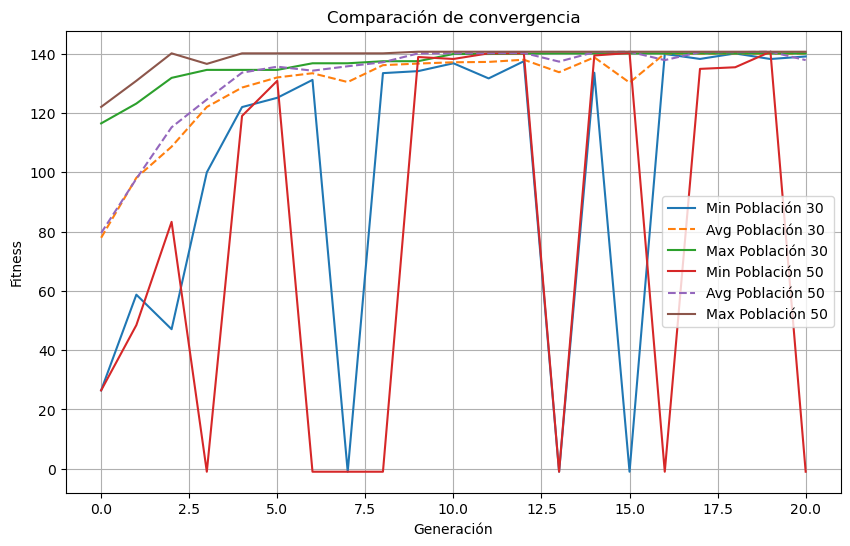

In [35]:
def graficar_convergencia_comparada(log1, log2, label1, label2):
    gen1 = np.array(log1.select("gen"))
    min1 = np.array(log1.select("min"), dtype=float)
    avg1 = np.array(log1.select("avg"), dtype=float)
    max1 = np.array(log1.select("max"), dtype=float)

    gen2 = np.array(log2.select("gen"))
    min2 = np.array(log2.select("min"), dtype=float)
    avg2 = np.array(log2.select("avg"), dtype=float)
    max2 = np.array(log2.select("max"), dtype=float)

    plt.figure(figsize=(10, 6))
    
    plt.plot(gen1, min1, label=f"Min {label1}")
    plt.plot(gen1, avg1, linestyle="--", label=f"Avg {label1}")
    plt.plot(gen1, max1, label=f"Max {label1}")
    
    plt.plot(gen2, min2, label=f"Min {label2}")
    plt.plot(gen2, avg2, linestyle="--", label=f"Avg {label2}")
    plt.plot(gen2, max2, label=f"Max {label2}")
    
    plt.xlabel("Generación")
    plt.ylabel("Fitness")
    plt.title("Comparación de convergencia")
    plt.grid(True)
    plt.legend()
    plt.show()

graficar_convergencia_comparada(
    resultado_30["logbook"],
    resultado_50["logbook"],
    "Población 30",
    "Población 50"
)